# **King County House Data** — Linear Regression (Gradient Descent)

**Bài toán:** Cho một tập dữ liệu về nhà ở với các đặc trưng như diện tích (square footage), số phòng ngủ, vị trí,... hãy dự đoán giá nhà (`price`) cho những ngôi nhà ở quận King, Washington, Hoa Kỳ.

**Mục tiêu:** Dự đoán giá nhà bằng **Linear Regression + Gradient Descent** để hiểu cách tối ưu tham số lặp, sử dụng dữ liệu đã tiền xử lý từ `Scripts/Pre_housing.ipynb`.

**Notebook:** `Model/LinearRegression_GD.ipynb`

**Mục lục:**

| # | Phase | Nội dung |
|---|-------|----------|
| 1 | [Chuẩn bị dữ liệu](#Phase-1-—-Chuẩn-bị-dữ-liệu) | Load dữ liệu, tách feature và target |
| 2 | [Định nghĩa mô hình](#Phase-2-—-Định-nghĩa-mô-hình) | Class Linear Regression (GD) & metrics |
| 3 | [Huấn luyện & dự đoán](#Phase-3-—-Huấn-luyện-&-dự-đoán) | Train trên `price_log`, predict, inverse `expm1` |
| 4 | [Đánh giá](#Phase-4-—-Đánh-giá-mô-hình) | Metric trên 3 tập (giá gốc USD) |
| 5 | [Trực quan hoá](#Phase-5-—-Trực-quan-hoá) | Loss curve, Actual vs Predicted, Residual |

## [Phase 1 — Chuẩn bị dữ liệu]

### Dữ liệu

**Nguồn:** `Data/kc_house_data_NaN.csv` → đã tiền xử lý bởi `Scripts/Pre_housing.ipynb`.

**Preprocessing (áp dụng khi load):**
- `y_train_log = log1p(price)` — target huấn luyện
- `y_train_price, y_val_price, y_test_price` — giá gốc USD, chỉ dùng đánh giá
- `X` = feature đã **StandardScaler**, **loại** `price_log` tránh data leakage

**Tổng quan các tập dữ liệu (70:15:15):**

| Tập | File | Số mẫu |
|-----|------|--------|
| Train | `Data/X_train.csv`, `Data/y_train.csv` | 15,128 |
| Validation | `Data/X_val.csv`, `Data/y_val.csv` | 3,243 |
| Test | `Data/X_test.csv`, `Data/y_test.csv` | 3,242 |

> **Lưu ý GD:** X đã được scale (mean ≈ 0, std ≈ 1 trên Train) → **không scale lại**. Chỉ train trên `y_train_log`.

In [14]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [15]:
# LOAD DATASET — 3 tập train / validation / test
ROOT = Path.cwd()
if ROOT.name in ("Model", "Scripts"):
    ROOT = ROOT.parent
DATA_DIR = ROOT / "Data"

DROP_COLS = ["price_log"]  # X không chứa price_log (đó là target / leakage)

X_train_df = pd.read_csv(DATA_DIR / "X_train.csv").drop(columns=DROP_COLS)
X_val_df   = pd.read_csv(DATA_DIR / "X_val.csv").drop(columns=DROP_COLS)
X_test_df  = pd.read_csv(DATA_DIR / "X_test.csv").drop(columns=DROP_COLS)

feature_names = list(X_train_df.columns)

X_train = X_train_df.values.astype(float)
X_val   = X_val_df.values.astype(float)
X_test  = X_test_df.values.astype(float)

# Giá gốc (USD) — dùng cho đánh giá & biểu đồ
y_train_price = pd.read_csv(DATA_DIR / "y_train.csv")["price"].values.astype(float)
y_val_price   = pd.read_csv(DATA_DIR / "y_val.csv")["price"].values.astype(float)
y_test_price  = pd.read_csv(DATA_DIR / "y_test.csv")["price"].values.astype(float)

# Target huấn luyện: price_log = log1p(price)
y_train_log = np.log1p(y_train_price)

print(f"Số feature trong X: {len(feature_names)} (đã loại price_log)")
print(f"Features: {feature_names}")
print(f"X_train: {X_train.shape}, y_train_log: {y_train_log.shape}")
print(f"X_val:   {X_val.shape},   y_val_price:   {y_val_price.shape}")
print(f"X_test:  {X_test.shape},  y_test_price:  {y_test_price.shape}")
print(f"\nMissing — Train: {np.isnan(X_train).sum()}, Val: {np.isnan(X_val).sum()}, Test: {np.isnan(X_test).sum()}")
print(f"X_train mean≈{X_train.mean():.4f}, std≈{X_train.std():.4f} (đã StandardScaler)")
print(f"y_train_price range: [{y_train_price.min():,.0f}, {y_train_price.max():,.0f}] USD")
print(f"y_train_log   range: [{y_train_log.min():.4f}, {y_train_log.max():.4f}]")

Số feature trong X: 22 (đã loại price_log)
Features: ['bedrooms', 'bathrooms', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sqft_living_log', 'month_sold', 'age', 'is_renovated', 'years_since_renovated', 'has_basement', 'distance_to_center', 'zipcode_freq']
X_train: (15128, 22), y_train_log: (15128,)
X_val:   (3243, 22),   y_val_price:   (3243,)
X_test:  (3242, 22),  y_test_price:  (3242,)

Missing — Train: 0, Val: 0, Test: 0
X_train mean≈-0.0000, std≈1.0000 (đã StandardScaler)
y_train_price range: [75,000, 7,700,000] USD
y_train_log   range: [11.2253, 15.8567]


## [Phase 2 — Định nghĩa mô hình]

### Class `LinearRegression` (Gradient Descent)

| Phương thức | Mô tả |
|-------------|--------|
| `fit(X, y)` | Batch GD, lưu `weights`, `bias`, `loss_history` |
| `predict(X)` | Trả về `X @ weights + bias` |

### Metrics

MSE, RMSE, MAE, MAPE, R² — tính trên **giá gốc USD** sau `expm1()`.

In [16]:
class LinearRegression:
    """Linear Regression optimized by batch Gradient Descent."""

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y, verbose_every=100):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for epoch in range(self.epochs):
            y_pred = X @ self.weights + self.bias
            error = y_pred - y

            dw = (2 / n_samples) * (X.T @ error)
            db = (2 / n_samples) * np.sum(error)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            loss = np.mean(error ** 2)
            self.loss_history.append(loss)

            if verbose_every and epoch % verbose_every == 0:
                print(f"Epoch {epoch:4d} | MSE (log-space) = {loss:.6f}")

        print(f"Training complete — final MSE (log) = {self.loss_history[-1]:.6f}")
        print(f"Bias = {self.bias:.6f}")
        print(f"Weights: shape={self.weights.shape}")

    def predict(self, X):
        return X @ self.weights + self.bias

In [17]:
# Evaluation Metrics

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)


def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def format_metric_table(df):
    """Format MSE/RMSE/MAE có dấu phẩy; R²/MAPE giữ 4 chữ số thập phân."""
    display_df = df.copy()
    for col in ["Train", "Val", "Test"]:
        formatted = []
        for metric, val in zip(display_df["Metric"], display_df[col]):
            if metric == "R²":
                formatted.append(f"{val:.4f}")
            elif metric == "MAPE":
                formatted.append(f"{val:.4f}%")
            else:
                formatted.append(f"{val:,.0f}")
        display_df[col] = formatted
    return display_df

## [Phase 3 — Huấn luyện & dự đoán]

**Pipeline 4 bước:**

```
X_scaled  →  fit(y_train_log)  →  pred_log  →  expm1()  →  pred_price (USD)
```

| Bước | Thao tác |
|------|----------|
| 3.1 Train | `model.fit(X_train, y_train_log)` bằng Gradient Descent |
| 3.2 Predict | Dự đoán `pred_log` trên Train / Val / Test |
| 3.3 Inverse log | `pred_price = np.expm1(pred_log)` |
| Đánh giá | So sánh `pred_price` với `y_*_price` gốc |

### 3.1 — Huấn luyện trên `price_log` (tập Train)

In [26]:
# Train trên price_log bằng Gradient Descent
# X đã StandardScaler → lr có thể lớn hơn khi feature chưa scale
model = LinearRegression(learning_rate=0.15, epochs=300)

print("Training...")
model.fit(X_train, y_train_log, verbose_every=20)

Training...
Epoch    0 | MSE (log-space) = 170.499174
Epoch   20 | MSE (log-space) = 0.058042
Epoch   40 | MSE (log-space) = 0.057122
Epoch   60 | MSE (log-space) = 0.056870
Epoch   80 | MSE (log-space) = 0.056782
Epoch  100 | MSE (log-space) = 0.056746
Epoch  120 | MSE (log-space) = 0.056729
Epoch  140 | MSE (log-space) = 0.056720
Epoch  160 | MSE (log-space) = 0.056714
Epoch  180 | MSE (log-space) = 0.056710
Epoch  200 | MSE (log-space) = 0.056707
Epoch  220 | MSE (log-space) = 0.056705
Epoch  240 | MSE (log-space) = 0.056703
Epoch  260 | MSE (log-space) = 0.056702
Epoch  280 | MSE (log-space) = 0.056701
Training complete — final MSE (log) = 0.056700
Bias = 13.047021
Weights: shape=(22,)


### 3.2 — Dự đoán `price_log` trên Train / Val / Test

In [19]:
# Dự đoán ra price_log
train_pred_price_log = model.predict(X_train)
val_pred_price_log   = model.predict(X_val)
test_pred_price_log  = model.predict(X_test)

print(f"Train pred_price_log: {train_pred_price_log.shape}")
print(f"Val pred_price_log:   {val_pred_price_log.shape}")
print(f"Test pred_price_log:  {test_pred_price_log.shape}")

Train pred_price_log: (15128,)
Val pred_price_log:   (3243,)
Test pred_price_log:  (3242,)


### 3.3 — Chuyển ngược `price_log` về `price` gốc

`expm1()` là phép ngược của `log1p()` dùng trong tiền xử lý:

$$\text{price} = \mathrm{expm1}(\text{price\_log}) = e^{\text{price\_log}} - 1$$

In [20]:
# Inverse: expm1(pred_log) → price gốc (USD)
train_pred_price = np.expm1(train_pred_price_log)
val_pred_price   = np.expm1(val_pred_price_log)
test_pred_price  = np.expm1(test_pred_price_log)

## [Phase 4 — Đánh giá mô hình]

Metric được tính trên **giá gốc USD** sau `expm1()`, trên cả 3 tập Train / Val / Test.

In [21]:
# Metrics GD trên price gốc
results_gd = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "MAPE", "R²"],
    "Train": [
        mse(y_train_price, train_pred_price),
        rmse(y_train_price, train_pred_price),
        mae(y_train_price, train_pred_price),
        mape(y_train_price, train_pred_price),
        r2_score(y_train_price, train_pred_price),
    ],
    "Val": [
        mse(y_val_price, val_pred_price),
        rmse(y_val_price, val_pred_price),
        mae(y_val_price, val_pred_price),
        mape(y_val_price, val_pred_price),
        r2_score(y_val_price, val_pred_price),
    ],
    "Test": [
        mse(y_test_price, test_pred_price),
        rmse(y_test_price, test_pred_price),
        mae(y_test_price, test_pred_price),
        mape(y_test_price, test_pred_price),
        r2_score(y_test_price, test_pred_price),
    ],
})

print("=== Gradient Descent (raw) ===")
display(results_gd)

print("\n=== Gradient Descent (formatted) ===")
display(format_metric_table(results_gd))

=== Gradient Descent (raw) ===


,Metric,Train,Val,Test
0,MSE,2.689706e+10,2.779286e+10,3.525231e+10
1,RMSE,1.640032e+05,1.667119e+05,1.877560e+05
2,MAE,1.003353e+05,1.006228e+05,1.060025e+05
3,MAPE,1.887292e+01,1.884144e+01,1.885205e+01
4,R²,7.957030e-01,7.884265e-01,7.690180e-01



=== Gradient Descent (formatted) ===


,Metric,Train,Val,Test
0,MSE,"26,897,055,895","27,792,855,625","35,252,305,431"
1,RMSE,"164,003","166,712","187,756"
2,MAE,"100,335","100,623","106,002"
3,MAPE,18.8729%,18.8414%,18.8520%
4,R²,0.7957,0.7884,0.7690


> **Ghi chú:**
> - **Train** trên `price_log = log1p(price)` → giảm ảnh hưởng outlier (nhà giá cực cao).
> - **Đánh giá** trên giá USD sau `expm1(pred_log)` → metric có ý nghĩa thực tế.
> - **X** đã StandardScaler → không inverse scale khi đánh giá; chỉ cần `expm1` cho y.
> - Tham chiếu OLS (cùng data): Test R² ≈ 0.77, MAPE ≈ 18.8%, RMSE ≈ $188,190.

## [Phase 5 — Trực quan hoá]

| Biểu đồ | Mục đích | Cách đọc nhanh |
|---------|----------|----------------|
| **Training Loss Curve** | Kiểm tra GD hội tụ | Loss giảm dần rồi ổn định |
| **Actual vs Predicted** | Xem dự đoán có gần giá thực không | Điểm càng sát đường chéo đỏ thì càng tốt |
| **Residual Plot** | Kiểm tra sai số còn lại | Điểm nên rải ngẫu nhiên, đối xứng quanh 0 |

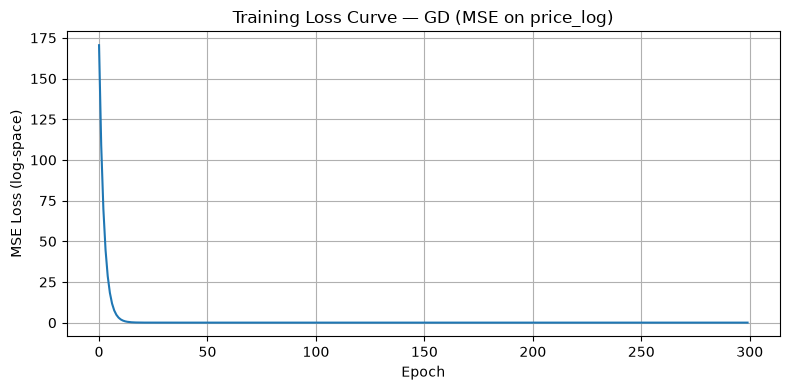

In [22]:
# Training Loss Curve (log-space MSE)
plt.figure(figsize=(8, 4))
plt.plot(model.loss_history)
plt.title("Training Loss Curve — GD (MSE on price_log)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log-space)")
plt.grid(True)
plt.tight_layout()
plt.show()

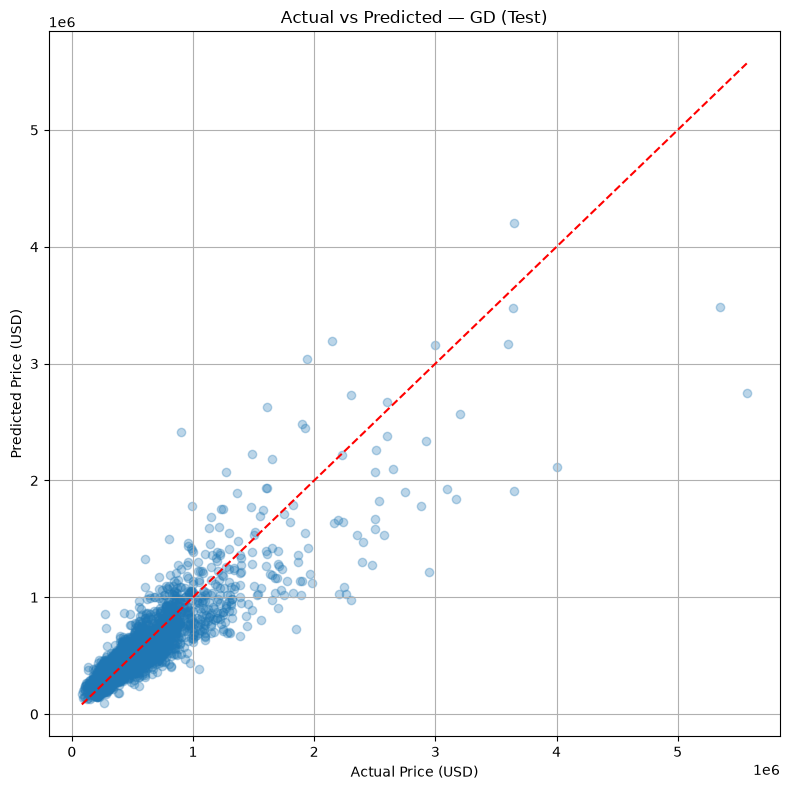

In [23]:
# Actual vs Predicted — Test (price gốc)
plt.figure(figsize=(8, 8))
plt.scatter(y_test_price, test_pred_price, alpha=0.3)
plt.plot(
    [y_test_price.min(), y_test_price.max()],
    [y_test_price.min(), y_test_price.max()],
    "r--",
)
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.title("Actual vs Predicted — GD (Test)")
plt.grid(True)
plt.tight_layout()
plt.show()

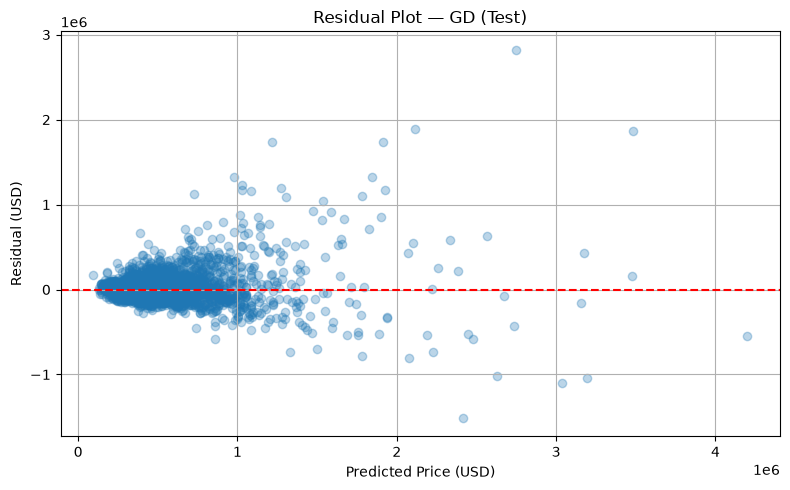

In [24]:
# Residual Plot — Test (price gốc)
residuals = y_test_price - test_pred_price

plt.figure(figsize=(8, 5))
plt.scatter(test_pred_price, residuals, alpha=0.3)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Predicted Price (USD)")
plt.ylabel("Residual (USD)")
plt.title("Residual Plot — GD (Test)")
plt.grid(True)
plt.tight_layout()
plt.show()